# Import libraries

In [1]:
import pandas as pd
import numpy as np
from os.path import join as pjoin
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)

plt.rcParams["text.usetex"] = False
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.sans-serif"] = "Arial"
plt.rcParams["font.size"] = 12
plt.rcParams["figure.dpi"] = 100

%config InlineBackend.figure_format = 'svg'
%matplotlib widget
%load_ext autoreload
%autoreload 2

# Load data

In [2]:
# %% Load data
animal = "GRB006"  # example animal
session = "20240723_142451"  # example session

data_dir = "/Users/gabriel/data"
trial_ts = pd.read_pickle(
    pjoin(data_dir, animal, session, "pre_processed", "trial_ts.pkl")
)
spike_times_per_unit = np.load(
    pjoin(data_dir, animal, session, "pre_processed", "spike_times_per_unit.npy"),
    allow_pickle=True,
)

trial_ts = trial_ts[
    trial_ts["stationary_stims"].apply(lambda x: len(x) > 0)
    & trial_ts["movement_stims"].apply(lambda x: len(x) > 0)
    & trial_ts["center_port_entries"].apply(lambda x: len(x) > 0)
].copy()

In [47]:
trial_ts

,category,trial_rate,detected_events,trial_start,stim_ts,first_stim_ts,stimulus_modality,response_side,correct_side,trial_outcome,center_port_entries,center_port_exits,left_port_entries,left_port_exits,right_port_entries,right_port_exits,response,stationary_stims,movement_stims
0,right,18,18,31.303967,"[33.270079134066144, 33.35001641306261, 33.390...",33.270079,audio-visual,1.0,1,1,[33.24276666666667],[33.795966666666665],[],[],[34.9702],[],34.970200,"[33.270079134066144, 33.35001641306261, 33.390...","[33.82997066666667, 33.86997066666667, 33.9500..."
3,right,14,14,44.579767,"[45.36212666666667, 45.40217466666667, 45.4422...",45.362127,audio-visual,1.0,1,1,[45.334833333333336],[45.9173],[],[],[47.046933333333335],[],47.046933,"[45.36212666666667, 45.40217466666667, 45.4422...","[45.96206266666666, 46.08211066666667, 46.1220..."
4,left,6,6,47.116700,"[51.324172, 51.404268, 51.60414, 51.804124, 51...",51.324172,audio-visual,0.0,0,1,[51.25703333333333],[51.86663333333333],[52.846333333333334],[],[50.37166666666667],"[49.8148, 50.5375]",52.846333,"[51.324172, 51.404268, 51.60414, 51.804124]","[51.964108, 52.08420400000001]"
7,right,20,20,61.732933,"[70.55421333333334, 70.67426133333333, 70.7141...",70.554213,audio-visual,1.0,1,1,[70.5241],[71.29923333333333],[],[],[72.60116666666667],[],72.601167,"[70.55421333333334, 70.67426133333333, 70.7141...","[71.31419733333333, 71.35424533333332, 71.3941..."
8,left,5,5,72.673800,"[76.17497999999999, 76.41501199999999, 76.5349...",76.174980,audio-visual,0.0,0,1,[76.1104],[76.77633333333333],[77.35683333333333],[],[],[75.42353333333334],77.356833,"[76.17497999999999, 76.41501199999999, 76.5349...",[76.85490968335493]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
819,right,16,16,4470.426700,"[4471.604168205333, 4471.644054875734, 4471.68...",4471.604168,audio-visual,0.0,1,0,[4471.5613],[4472.130133333333],[4472.639066666667],[4472.9554],[],[],4472.639067,"[4471.604168205333, 4471.644054875734, 4471.68...","[4472.163989544, 4472.2040362090665, 4472.2440..."
821,right,20,20,4478.887200,"[4479.581993333334, 4479.661881333333, 4479.74...",4479.581993,audio-visual,1.0,1,1,[4479.4714],[4480.083566666666],[],[],[4480.805966666667],[],4480.805967,"[4479.581993333334, 4479.661881333333, 4479.74...","[4480.101833333333, 4480.141833333333, 4480.18..."
822,right,16,16,4480.879633,"[4484.056087999999, 4484.176136, 4484.33612, 4...",4484.056088,audio-visual,1.0,1,1,[4483.992766666666],[4484.849],[],[],[4486.188233333333],[4482.969733333333],4486.188233,"[4484.056087999999, 4484.176136, 4484.33612, 4...","[4484.856126494824, 4484.896015133042, 4484.97..."
823,left,10,10,4486.264000,"[4490.458149333333, 4490.578085333334, 4490.93...",4490.458149,audio-visual,0.0,0,1,[4490.405266666667],[4490.9473],[4491.739933333333],[],[4489.4578],"[4489.410966666666, 4489.830766666667]",4491.739933,"[4490.458149333333, 4490.578085333334, 4490.93...","[4490.978101333333, 4491.098037333333, 4491.13..."


In [46]:
portTimes = trial_ts["center_port_entries"].to_numpy()
display(portTimes[118])  # Displays the empty value

stimTimes = trial_ts["first_stim_ts"].to_numpy()
display(stimTimes[263] - portTimes[263][0])  # displays the 231.9 ms delay

[1204.1219333333333]

0.11044193546649694

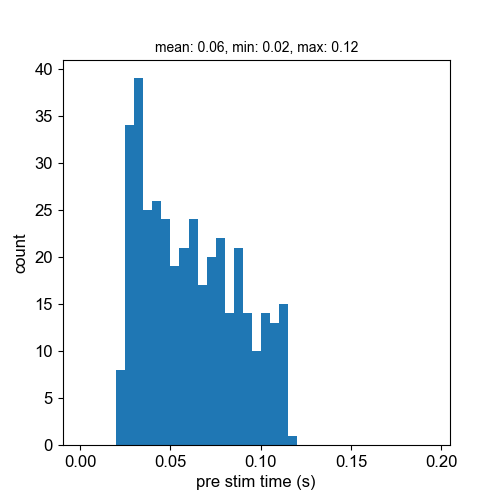

In [43]:
data = pd.DataFrame(
    {
        "center_entries": trial_ts.center_port_entries.apply(lambda x: x[0]),
        "first_stim": trial_ts.first_stim_ts,
        "pre_stim_time": trial_ts.first_stim_ts
        - trial_ts.center_port_entries.apply(lambda x: x[0]),
    }
)

fig, ax = plt.subplots(1, figsize=(5, 5))
ax.hist(data.pre_stim_time, bins=np.arange(0, 0.2, 0.005))
ax.set_xlabel("pre stim time (s)")
ax.set_ylabel("count")
ax.set_title(
    f"mean: {data.pre_stim_time.mean():.2f}, min: {data.pre_stim_time.min():.2f}, max: {data.pre_stim_time.max():.2f}",
    fontsize=10,
);

In [40]:
data.pre_stim_time.max()

0.1150559999999814